# SAD — Sistema de Apoio à Decisão para Logística Interna
## Análise Exploratória dos Dados

Objetivo: entender o comportamento dos dados gerados, identificar padrões
de execução por operador, distribuição de tempos, dados sujos e base
para o motor de score de atribuição de OS.

**Banco:** PostgreSQL — sad_logistica  
**Dados:** sintéticos, 90 dias de operação simulada  
**Tabelas principais:** os, os_itens, execucoes, operadores, enderecos

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from pathlib import Path
from urllib.parse import quote_plus

env_path = Path("..") / ".env"
load_dotenv(env_path)

db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")

if not all([db_user, db_password, db_host, db_port, db_name]):
    raise ValueError("Variáveis de ambiente não configuradas corretamente")

db_password_encoded = quote_plus(db_password)

engine = create_engine(
    f"postgresql+psycopg2://{db_user}:{db_password_encoded}@{db_host}:{db_port}/{db_name}"
)

print("Conexão OK")

Conexão OK


In [2]:
tabelas = [
    "depositos", "operadores", "produtos", "enderecos",
    "estoque", "os", "os_itens", "execucoes"
]

resumo = []
for tabela in tabelas:
    df = pd.read_sql(f"SELECT COUNT(*) AS total FROM {tabela}", engine)
    resumo.append({"tabela": tabela, "registros": df["total"][0]})

df_resumo = pd.DataFrame(resumo)
df_resumo

,tabela,registros
0,depositos,2
1,operadores,50
2,produtos,200
3,enderecos,860
4,estoque,411
5,os,600
6,os_itens,3378
7,execucoes,667


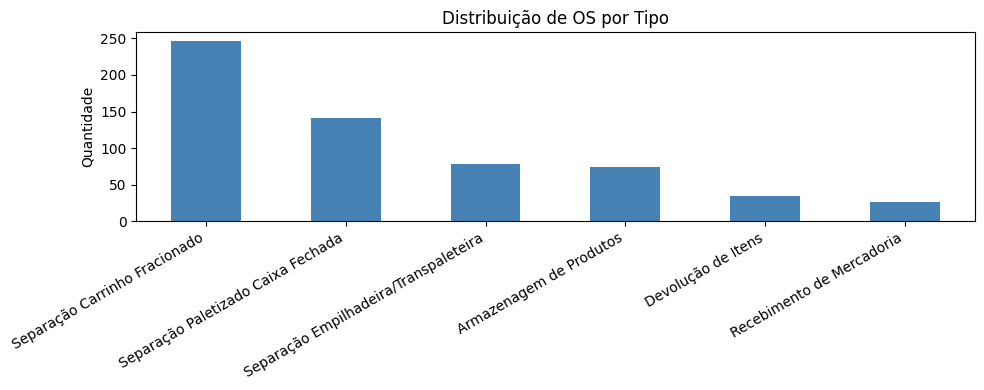

In [3]:
df_tipos = pd.read_sql("""
    SELECT 
        ot.descricao AS tipo,
        COUNT(*) AS quantidade
    FROM os o
    JOIN os_tipos ot ON ot.codigo = o.tipo_codigo
    GROUP BY ot.descricao
    ORDER BY quantidade DESC
""", engine)

df_tipos.plot(
    kind="bar",
    x="tipo",
    y="quantidade",
    legend=False,
    color="steelblue",
    figsize=(10, 4)
)
plt.title("Distribuição de OS por Tipo")
plt.xlabel("")
plt.ylabel("Quantidade")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

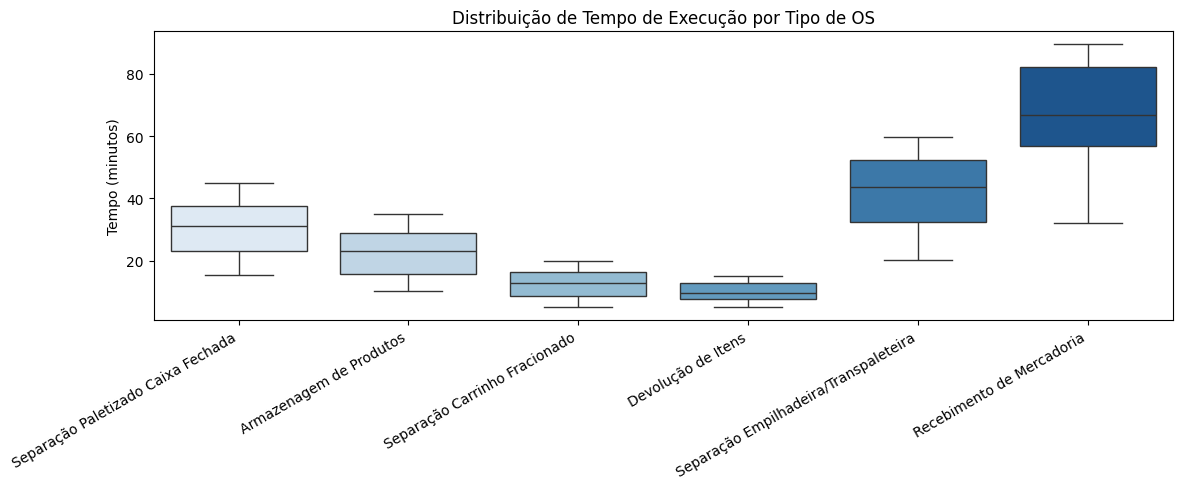

In [4]:
df_tempo = pd.read_sql("""
    SELECT 
        ex.tempo_segundos / 60.0 AS tempo_minutos,
        ot.descricao AS tipo
    FROM execucoes ex
    JOIN os o        ON o.id = ex.os_id
    JOIN os_tipos ot ON ot.codigo = o.tipo_codigo
    WHERE ex.status = 'finalizada'
      AND ex.tempo_segundos BETWEEN 60 AND 7200
""", engine)

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_tempo,
    x="tipo",
    y="tempo_minutos",
    hue="tipo",
    palette="Blues",
    legend=False
)
plt.title("Distribuição de Tempo de Execução por Tipo de OS")
plt.xlabel("")
plt.ylabel("Tempo (minutos)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [5]:
df_sujos = pd.read_sql("""
    SELECT 
        ex.id,
        ex.operador_id,
        ex.tempo_segundos,
        ex.tempo_segundos / 60.0 AS tempo_minutos,
        ot.descricao AS tipo
    FROM execucoes ex
    JOIN os o        ON o.id = ex.os_id
    JOIN os_tipos ot ON ot.codigo = o.tipo_codigo
    WHERE ex.status = 'finalizada'
      AND (ex.tempo_segundos < 60 OR ex.tempo_segundos > 7200)
""", engine)

print(f"Registros com tempo suspeito: {len(df_sujos)}")
df_sujos

Registros com tempo suspeito: 15


,id,operador_id,tempo_segundos,tempo_minutos,tipo
0,36,12,5,0.083333,Armazenagem de Produtos
1,86,34,10,0.166667,Separação Carrinho Fracionado
2,156,10,99999,1666.650000,Separação Carrinho Fracionado
3,211,15,0,0.000000,Separação Carrinho Fracionado
4,328,47,0,0.000000,Separação Empilhadeira/Transpaleteira
5,364,28,0,0.000000,Separação Carrinho Fracionado
6,391,32,0,0.000000,Separação Carrinho Fracionado
7,398,25,10,0.166667,Separação Paletizado Caixa Fechada
8,440,25,0,0.000000,Separação Paletizado Caixa Fechada
9,444,3,0,0.000000,Separação Carrinho Fracionado


In [6]:
df_baseline = pd.read_sql("""
    SELECT 
        op.nome AS operador,
        ot.descricao AS tipo,
        COUNT(*) AS total_execucoes,
        ROUND(AVG(ex.tempo_segundos) / 60.0, 1) AS tempo_medio_min,
        ROUND(STDDEV(ex.tempo_segundos) / 60.0, 1) AS desvio_padrao_min
    FROM execucoes ex
    JOIN operadores op ON op.id = ex.operador_id
    JOIN os o          ON o.id = ex.os_id
    JOIN os_tipos ot   ON ot.codigo = o.tipo_codigo
    WHERE ex.status = 'finalizada'
      AND ex.tempo_segundos BETWEEN 60 AND 7200
    GROUP BY op.nome, ot.descricao
    ORDER BY tipo, tempo_medio_min
""", engine)

df_baseline

,operador,tipo,total_execucoes,tempo_medio_min,desvio_padrao_min
0,Thomas Vargas,Armazenagem de Produtos,1,12.1,NaN
1,Rafael Aragão,Armazenagem de Produtos,2,12.8,0.0
2,Ravi Souza,Armazenagem de Produtos,2,13.3,1.2
3,Enzo Castro,Armazenagem de Produtos,2,13.5,1.0
4,Davi Costa,Armazenagem de Produtos,3,14.6,5.0
...,...,...,...,...,...
157,Sr. Davi Lucas Montenegro,Separação Paletizado Caixa Fechada,2,40.4,0.9
158,Enzo Castro,Separação Paletizado Caixa Fechada,1,41.0,NaN
159,Isabela Dias,Separação Paletizado Caixa Fechada,2,41.7,0.2
160,Olívia Caldeira,Separação Paletizado Caixa Fechada,1,43.1,NaN


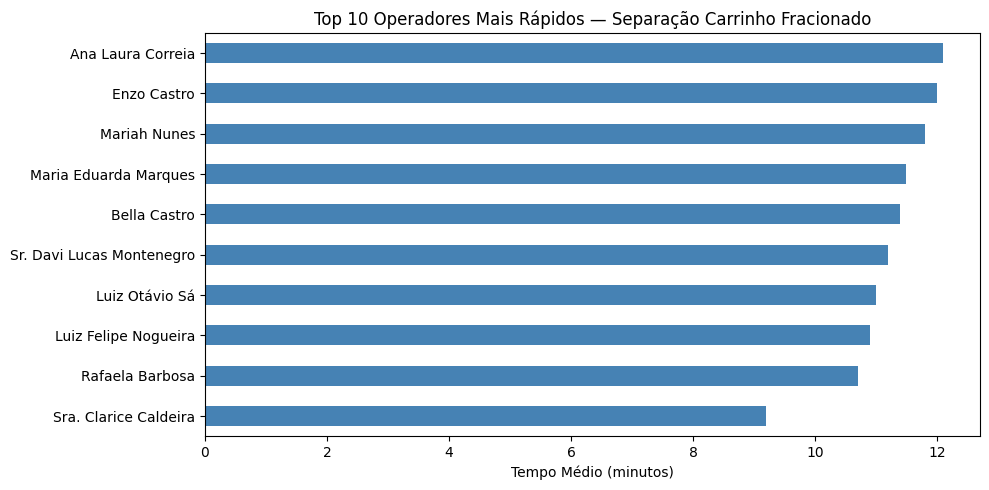

In [7]:
df_top = pd.read_sql("""
    SELECT 
        op.nome AS operador,
        ROUND(AVG(ex.tempo_segundos) / 60.0, 1) AS tempo_medio_min,
        COUNT(*) AS execucoes
    FROM execucoes ex
    JOIN operadores op ON op.id = ex.operador_id
    JOIN os o          ON o.id = ex.os_id
    WHERE ex.status = 'finalizada'
      AND o.tipo_codigo = 1
      AND ex.tempo_segundos BETWEEN 60 AND 7200
    GROUP BY op.nome
    HAVING COUNT(*) >= 3
    ORDER BY tempo_medio_min
    LIMIT 10
""", engine)

df_top.plot(
    kind="barh",
    x="operador",
    y="tempo_medio_min",
    legend=False,
    color="steelblue",
    figsize=(10, 5)
)
plt.title("Top 10 Operadores Mais Rápidos — Separação Carrinho Fracionado")
plt.xlabel("Tempo Médio (minutos)")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [8]:
df_reatrib = pd.read_sql("""
    SELECT
        os_id,
        COUNT(*) AS total_execucoes
    FROM execucoes
    GROUP BY os_id
    HAVING COUNT(*) > 1
""", engine)

print(f"OS com reatribuição: {len(df_reatrib)}")
print(f"Total de OS: 600")
print(f"Taxa de reatribuição: {len(df_reatrib)/600*100:.1f}%")

OS com reatribuição: 67
Total de OS: 600
Taxa de reatribuição: 11.2%


In [9]:
df_concorrencia = pd.read_sql("""
    SELECT
        e1.id AS execucao_id,
        e1.operador_id,
        e1.inicio,
        e1.fim,
        e1.tempo_segundos,
        COUNT(e2.id) AS operadores_simultaneos
    FROM execucoes e1
    JOIN execucoes e2
        ON e2.id != e1.id
        AND e2.inicio < e1.fim
        AND e2.fim > e1.inicio
        AND e2.status = 'finalizada'
    WHERE e1.status = 'finalizada'
      AND e1.tempo_segundos BETWEEN 60 AND 7200
    GROUP BY e1.id, e1.operador_id, e1.inicio, e1.fim, e1.tempo_segundos
    ORDER BY operadores_simultaneos DESC
""", engine)

print(f"Execuções analisadas: {len(df_concorrencia)}")
print(f"\nDistribuição de operadores simultâneos:")
print(df_concorrencia["operadores_simultaneos"].describe())

Execuções analisadas: 193

Distribuição de operadores simultâneos:
count    193.000000
mean       1.202073
std        0.439692
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: operadores_simultaneos, dtype: float64


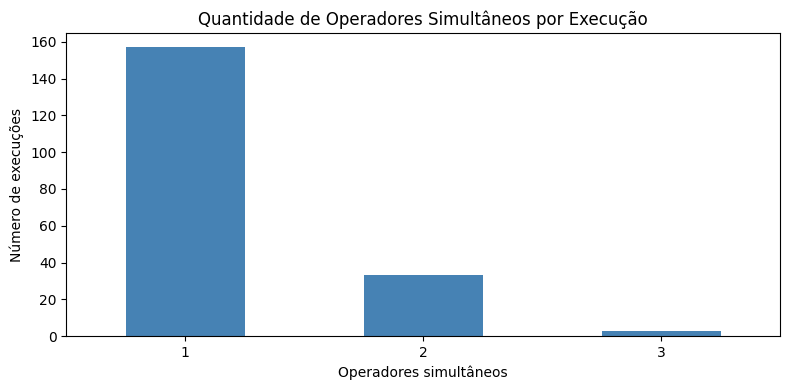

In [10]:
contagem = df_concorrencia["operadores_simultaneos"].value_counts().sort_index()

contagem.plot(
    kind="bar",
    color="steelblue",
    figsize=(8, 4)
)
plt.title("Quantidade de Operadores Simultâneos por Execução")
plt.xlabel("Operadores simultâneos")
plt.ylabel("Número de execuções")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
df_provisorio = pd.read_sql("""
    SELECT
        dado_provisorio,
        COUNT(*) AS total,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS percentual
    FROM produtos
    GROUP BY dado_provisorio
""", engine)

print("Qualidade dos dados logísticos:")
print(df_provisorio.to_string(index=False))

Qualidade dos dados logísticos:
 dado_provisorio  total  percentual
           False    147        73.5
            True     53        26.5


In [12]:
## Conclusões da Análise Exploratória

### ✅ Qualidade dos dados
- **15 registros** com tempo suspeito detectados (< 1 min ou > 2 h)
- Esses registros serão excluídos do motor de score
- **~25% dos produtos** com dados logísticos provisórios - precisam de revisão

### ✅ Padrões operacionais
- Separação Carrinho Fracionado domina o volume (~40% das OS)
- Tempos médios coerentes por tipo: Carrinho ~15 min, Paletizado ~30 min, Empilhadeira ~40 min
- Taxa de reatribuição de **11.2%** - sinal de que o motor de decisão tem espaço para reduzir isso

### ✅ Concorrência
- Máximo de 3 operadores simultâneos detectado
- Base confirmada para o cálculo de interferência no motor de score

### 🔜 Próximo passo
Construção do motor de score de atribuição de OS

SyntaxError: invalid syntax (4112786993.py, line 4)